In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install datasets
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


In [3]:
from datasets import *
folder = '/content/drive/MyDrive/TransformesCod/05-Service_Center/'

pre_training_dataset = load_from_disk(folder + 'pre_training_dataset')
pre_PublicTest_dataset = load_from_disk(folder + 'pre_PublicTest_dataset')
pre_PrivateTest_dataset = load_from_disk(folder + 'pre_PrivateTest_dataset')


In [4]:
pre_training_dataset

Dataset({
    features: ['labels', 'img', 'pixel_values'],
    num_rows: 6104
})

In [5]:
model_id="google/vit-base-patch16-224-in21k"

In [6]:
import torch
import torch.nn as nn
from transformers import ViTModel
from transformers.modeling_outputs import SequenceClassifierOutput

In [22]:
class FitForImageClassification(nn.Module):
    def __init__(self, num_labels=7):
      super(FitForImageClassification, self).__init__()
      self.vit = ViTModel.from_pretrained(model_id)
      self.dropout = nn.Dropout(0.1)
      self.classifier = nn.Linear(self.vit.config.hidden_size, num_labels)
      self.num_labels = num_labels
    def forward(self, pixel_values, labels=None):
      outputs = self.vit(pixel_values=pixel_values)
      output = self.dropout(outputs.last_hidden_state[:,0])
      logits = self.classifier(output)
      if labels is not None:
        if isinstance(labels , list):
          labels = torch.tensor(labels , dtype=torch.long , device=logits.device)
        loss_fct = nn.CrossEntropyLoss()
        pred_logits = logits.view(-1, self.num_labels)
        labels = labels.view(-1)
        loss = loss_fct(pred_logits, labels.view(-1))
        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,)
      else :
        return logits

In [8]:
from transformers import TrainingArguments, Trainer
matric_name = 'accuracy'
args = TrainingArguments(
    output_dir="output-fer",
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model=matric_name,
    logging_dir='logs',
    report_to='none',
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [9]:
from evaluate import load
import numpy as np
metric = load("accuracy" , trust_remote_code=True)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [10]:
model = FitForImageClassification()

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [11]:
trainer = Trainer(
    model,
    args,
    train_dataset=pre_training_dataset,
    eval_dataset=pre_PublicTest_dataset,
    compute_metrics=compute_metrics
)

In [12]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.292974,0.547194
2,1.431319,1.157216,0.582908
3,0.911277,1.138576,0.584184
4,0.608665,1.154693,0.607143
5,0.608665,1.210029,0.605867
6,0.372758,1.300540,0.579082
7,0.229629,1.362715,0.585459
8,0.155406,1.414811,0.577806


TrainOutput(global_step=3056, training_loss=0.6095419853769671, metrics={'train_runtime': 3764.19, 'train_samples_per_second': 12.973, 'train_steps_per_second': 0.812, 'total_flos': 0.0, 'train_loss': 0.6095419853769671, 'epoch': 8.0})

In [15]:

outputs = trainer.predict(pre_PrivateTest_dataset)
accuracy_result = compute_metrics((outputs.predictions, outputs.label_ids))
print("Test Accuracy:", round(100*accuracy_result["accuracy"],2))

Test Accuracy: 67.01


In [38]:
import torch
from PIL import Image
import numpy as np
from transformers import ViTImageProcessor
import matplotlib.pyplot as plt

model_id = 'google/vit-base-patch16-224-in21k'
processor = ViTImageProcessor.from_pretrained(model_id)

classes_names = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Sadness', 'Surprise','Neutral' ]

def classify_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image_np = np.array(image)
    inputs = processor(images=image_np, return_tensors="pt").to("cpu")

    model.eval()
    model.to("cpu")
    with torch.no_grad():
        logits = model(**inputs)


    predicted_index = torch.argmax(logits, dim=1).item()

    result_name = classes_names[predicted_index]


    plt.imshow(image)
    plt.title(f"Prediction: {result_name}", fontsize=16, color='green')
    plt.axis('off')
    plt.show()


    return result_name

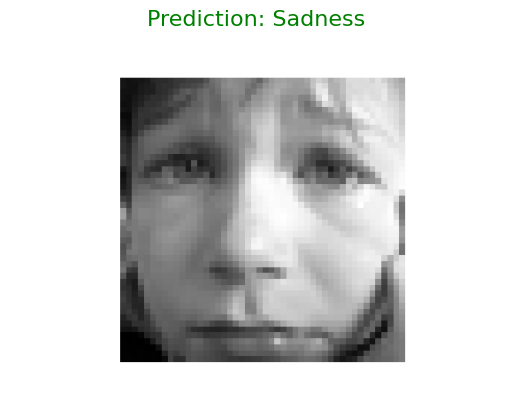

النتيجة: Sadness


In [39]:

result = classify_image("/content/drive/MyDrive/TransformesCod/05-Service_Center/photos/Sadness6.png")
print(f"النتيجة: {result}")

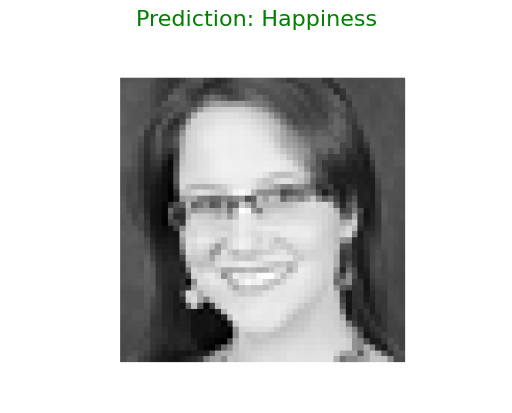

النتيجة: Happiness


In [40]:
result = classify_image("/content/drive/MyDrive/TransformesCod/05-Service_Center/photos/Happiness7.png")
print(f"النتيجة: {result}")

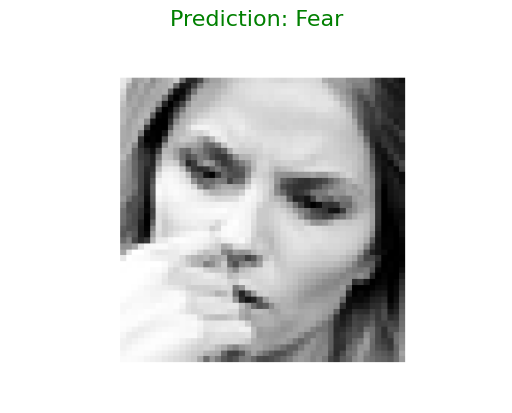

النتيجة: Fear


In [41]:
result = classify_image("/content/drive/MyDrive/TransformesCod/05-Service_Center/photos/Fear2.png")
print(f"النتيجة: {result}")